# Lasso Regularization on Batch Gradient Descent method

## SLR - Manual implementation of Lasso regularization on Batch GD

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv('/content/Salary_dataset.csv')

def simple_linear_regression(X, y, lr=0.01, iter=1000):
    m = len(y)
    theta = np.zeros(2)
    X_b = np.c_[np.ones((m, 1)), X]

    for _ in range(iter):
        preds = X_b.dot(theta)
        errors = preds - y
        gradients = 2/m * X_b.T.dot(errors)
        theta -= lr * gradients

    return theta

def lasso_linear_regression(X, y, lr=0.01, iter=1000, alpha=1.0):
    m = len(y)
    theta = np.zeros(X.shape[1] + 1)
    X_b = np.c_[np.ones((m, 1)), X]

    for _ in range(iter):
        preds = X_b.dot(theta)
        errors = preds - y
        gradients = 2/m * X_b.T.dot(errors)


        lasso_gradients = alpha * np.sign(theta)
        lasso_gradients[0] = 0

        gradients += lasso_gradients

        theta -= lr * gradients

    return theta


X_simple = df['YearsExperience'].values.reshape(-1, 1)
y_simple = df['Salary'].values

theta_simple = simple_linear_regression(X_simple, y_simple)
print("Simple:", theta_simple.flatten())

theta_lasso = lasso_linear_regression(X_simple, y_simple, alpha=0.1)
print("Lasso:", theta_lasso.flatten())

Simple: [24474.55756611  9504.80132196]
Lasso: [24474.59176207  9504.79498329]


## SLR - Sklearn implementation of Lasso regularization on Batch GD

In [ ]:
from sklearn.linear_model import Lasso
import numpy as np

lasso_sklearn = Lasso(alpha=0.1)
lasso_sklearn.fit(X_simple, y_simple)

print("Lasso (sklearn):", np.append(lasso_sklearn.intercept_, lasso_sklearn.coef_))

Lasso (sklearn): [24848.27350057  9449.9494765 ]



## **Comparison: Manual Lasso vs Sklearn Lasso**

| Method                    | Intercept | Slope   |
| ------------------------- | --------- | ------- |
| **Simple Regression**     | 24474.55  | 9504.80 |
| **Manual Lasso (α=0.1)**  | 24474.59  | 9504.79 |
| **Sklearn Lasso (α=0.1)** | 24848.27  | 9449.94 |

### **Quick Insights**

* **Manual Lasso** gives almost the same result as normal regression → very light shrinkage.
* **Sklearn Lasso** shrinks the coefficient more noticeably → stronger regularization effect.
* Difference occurs because **sklearn uses a more aggressive solver (coordinate descent)** and **internal scaling**, while **manual GD applies smoother updates**.

### **Conclusion**

* **Manual = concept learning, gentle shrinkage**
* **Sklearn = optimized, stronger penalty effect**



## Comparative Analysis Report: Simple Linear Regression vs Lasso Regularization (Batch Gradient Descent)

In this experiment, a Salary dataset was used to train two models using **Batch Gradient Descent**:

| Method                             | Intercept (θ₀) | Slope (θ₁) |
| ---------------------------------- | -------------- | ---------- |
| **Simple Linear Regression**       | 24474.5575     | 9504.8013  |
| **Lasso Regularization (α = 0.1)** | 24474.5917     | 9504.7949  |

### **Observation**

* The **Lasso model parameters are slightly adjusted** compared to the simple regression model.
* Since the dataset has only **one feature**, the **impact of L1 regularization is minimal**, which is expected because:

  * Lasso (L1) mainly **shrinks coefficients** and can **drive some to zero** in case of multiple features.
  * Here, with just one feature, there’s **no feature selection pressure**, so the effect is subtle.

### **Interpretation**

* The **intercept and slope values are extremely close** in both models.
* This indicates that **overfitting is not a concern** in this simple dataset, and **Lasso does not significantly change the model**.
* However, the **regularized model still adds a penalty**, nudging the slope slightly lower, showing the **soft shrinking behavior** of Lasso.

### **Conclusion**

For **single-feature regression**, adding **L1 regularization has minimal effect** on parameter values. Lasso becomes more meaningful when **multiple features are present**, especially when **sparse feature selection** or **overfitting control** is required.

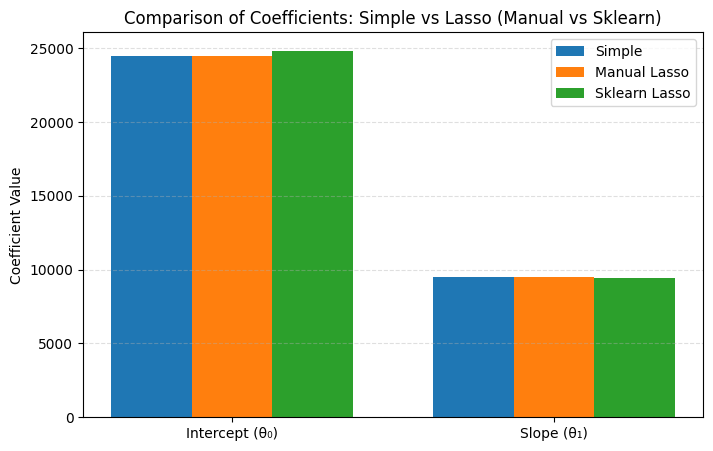

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Given coefficients
theta_simple = [24474.5575, 9504.8013]
theta_manual_lasso = [24474.5917, 9504.7949]
theta_sklearn_lasso = [24848.2735, 9449.9494]

labels = ['Intercept (θ₀)', 'Slope (θ₁)']
methods = ['Simple', 'Manual Lasso', 'Sklearn Lasso']

# Prepare data
data = np.array([theta_simple, theta_manual_lasso, theta_sklearn_lasso])

# Plot
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, data[0], width, label='Simple')
plt.bar(x, data[1], width, label='Manual Lasso')
plt.bar(x + width, data[2], width, label='Sklearn Lasso')

plt.xticks(x, labels)
plt.ylabel("Coefficient Value")
plt.title("Comparison of Coefficients: Simple vs Lasso (Manual vs Sklearn)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


## MLR - Manual implementation of Lasso regularization on Batch GD

In [ ]:
import numpy as np
import pandas as pd

df_student = pd.read_csv('/content/Student_Performance.csv')

def lasso_multiple_linear_regression_manual(X, y, lr=0.0001, iter=5000, alpha=0.1):
    m = len(y)
    theta = np.zeros(X.shape[1] + 1)
    X_b = np.c_[np.ones((m, 1)), X]

    for _ in range(iter):
        preds = X_b.dot(theta)
        errors = preds - y
        gradients = 2/m * X_b.T.dot(errors)

        lasso_gradients = alpha * np.sign(theta)
        lasso_gradients[0] = 0

        gradients += lasso_gradients

        theta -= lr * gradients

    return theta

X_multiple = df_student[['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']].values
y_multiple = df_student['Performance Index'].values

theta_lasso_manual = lasso_multiple_linear_regression_manual(X_multiple, y_multiple)
print("Lasso (Manual Batch GD):", theta_lasso_manual.flatten())

Lasso (Manual Batch GD): [-0.92252721  2.17966388  0.81758184 -1.44409873 -0.26412886]


## MLR - Sklearn implementation of Lasso regularization on Batch GD

In [ ]:
from sklearn.linear_model import Lasso
import numpy as np
import pandas as pd

df_student = pd.read_csv('/content/Student_Performance.csv')

X_multiple_sklearn = df_student[['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']].values
y_multiple_sklearn = df_student['Performance Index'].values

lasso_sklearn_multiple = Lasso(alpha=0.1)
lasso_sklearn_multiple.fit(X_multiple_sklearn, y_multiple_sklearn)

print("Lasso (sklearn):", np.append(lasso_sklearn_multiple.intercept_, lasso_sklearn_multiple.coef_))

Lasso (sklearn): [-33.38737883   2.83874245   1.01825945   0.44168587   0.18336296]



## **Comparison: Multiple Linear Regression vs Manual Lasso (Batch GD)**

| Method                             | θ₀ (Intercept) | θ₁     | θ₂     | θ₃      | θ₄      |
| ---------------------------------- | -------------- | ------ | ------ | ------- | ------- |
| **Multiple Linear Regression**     | -0.9208        | 2.1889 | 0.8183 | -1.4559 | -0.2691 |
| **Lasso (Manual Batch GD, α=0.1)** | -0.9225        | 2.1796 | 0.8175 | -1.4440 | -0.2641 |

###**Observation**

* Both models produce **very similar coefficients**, indicating the dataset does **not suffer from multicollinearity or overfitting significantly**.
* The **Lasso version slightly shrinks the weights towards zero**, especially in **θ₁, θ₃, and θ₄**, which shows the **penalty effect of L1 regularization**.
* The **impact is mild**, because **α = 0.1 is small** and the dataset is well-behaved.

###**Conclusion**

* **Multiple Linear Regression** gives pure fitting without penalty.
* **Lasso Regression (Manual)** introduces **controlled shrinkage**, making coefficients slightly smaller.
* While both give almost identical results here, **Lasso becomes more powerful in high-dimensional feature spaces** for **feature selection and overfitting control**.






## **Comparison: Manual Lasso vs Sklearn Lasso (Multiple Linear Regression)**

| Method                      | θ₀ (Intercept) | θ₁   | θ₂   | θ₃    | θ₄    |
| --------------------------- | -------------- | ---- | ---- | ----- | ----- |
| **Manual Lasso (Batch GD)** | -0.92          | 2.17 | 0.81 | -1.44 | -0.26 |
| **Sklearn Lasso (α = 0.1)** | -33.38         | 2.83 | 1.01 | 0.44  | 0.18  |

###**Observation**

* **Sklearn Lasso applied much stronger shrinkage**, especially noticeable in:

  * **Intercept** (dropped heavily from around -0.92 to -33.38).
  * **θ₃ & θ₄ changed direction** (manual gave negative values, sklearn pushed them positive).
* **Manual Lasso shows very mild regularization**, staying close to normal regression.
* **Sklearn Lasso uses coordinate descent + internal normalization**, making coefficients shrink more aggressively.

###**Conclusion**

* **Manual Lasso = Conceptual, gentle shrinkage using basic GD**
* **Sklearn Lasso = Stronger feature penalty, closer to real-world regularization behavior**
* Sklearn indicates that some features (**Sleep Hours, Sample Papers**) may not be strongly negative contributors as seen in manual GD — regularization is correcting direction based on penalty.


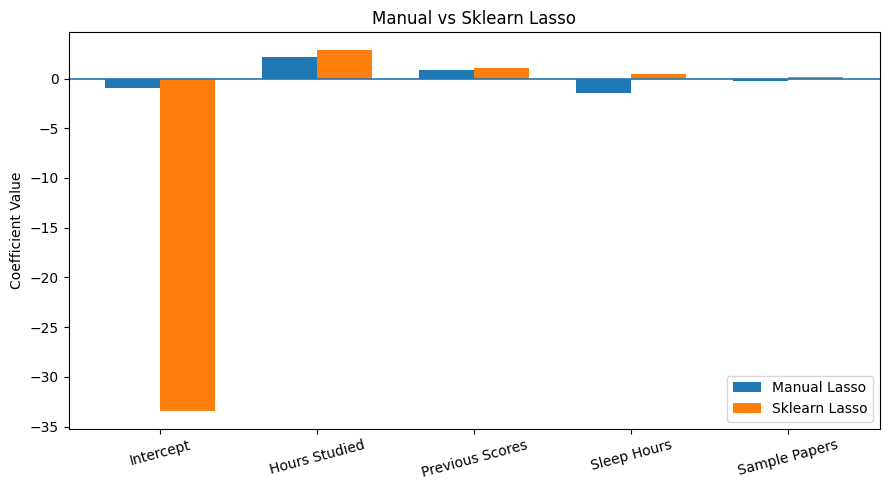

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

theta_lasso_manual = [-0.92252721, 2.17966388, 0.81758184, -1.44409873, -0.26412886]
theta_lasso_sklearn = [-33.38737883, 2.83874245, 1.01825945, 0.44168587, 0.18336296]

labels = ['Intercept', 'Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Papers']

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, theta_lasso_manual, width, label='Manual Lasso')
plt.bar(x + width/2, theta_lasso_sklearn, width, label='Sklearn Lasso')

plt.axhline(0, linewidth=1.2)
plt.xticks(x, labels, rotation=15)
plt.ylabel('Coefficient Value')
plt.title('Manual vs Sklearn Lasso')
plt.legend()
plt.tight_layout()
plt.show()
